# E-commerce Sales Analysis

# ============================================
# 1. IMPORTS
# ============================================

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

# ============================================
# 2. DATA LOADING
# ============================================

In [3]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

In [4]:
print("Dataset carregado com sucesso.")
print(f"Shape: {df.shape}")

Dataset carregado com sucesso.
Shape: (9994, 21)


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# ============================================
# 3. INITIAL AUDIT
# ============================================

In [6]:
print("\n--- Info ---")
df.info()

print("\n--- Estatísticas descritivas (numéricas) ---")
df.describe()

print("\n--- Valores únicos por coluna ---")
print(df.nunique())

print("\n--- Duplicatas ---")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

print("\n--- Categorias ---")
print(df["Category"].unique())

print("\n--- Descontos únicos ---")
print(sorted(df["Discount"].unique()))


--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quant

# ============================================
# 4. DATA PREPARATION
# ============================================

In [7]:
# Converter datas
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Features temporais
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.to_period("M")

# Dias de envio
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("\nPreparação concluída.")
print(df[["Order Date", "Ship Date", "Order Year", "Order Month", "Shipping Days"]].head())


Preparação concluída.
  Order Date  Ship Date  Order Year Order Month  Shipping Days
0 2016-11-08 2016-11-11        2016     2016-11              3
1 2016-11-08 2016-11-11        2016     2016-11              3
2 2016-06-12 2016-06-16        2016     2016-06              4
3 2015-10-11 2015-10-18        2015     2015-10              7
4 2015-10-11 2015-10-18        2015     2015-10              7


# ============================================
# 5. OVERALL SALES & PROFIT
# ============================================

In [8]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Margin: {overall_margin:.2%}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Margin: 12.47%


# ============================================
# 6. CATEGORY ANALYSIS
# ============================================


--- Category Performance ---
                       Sales       Profit    Margin
Category                                           
Technology       836154.0330  145454.9481  0.173957
Office Supplies  719047.0320  122490.8008  0.170352
Furniture        741999.7953   18451.2728  0.024867


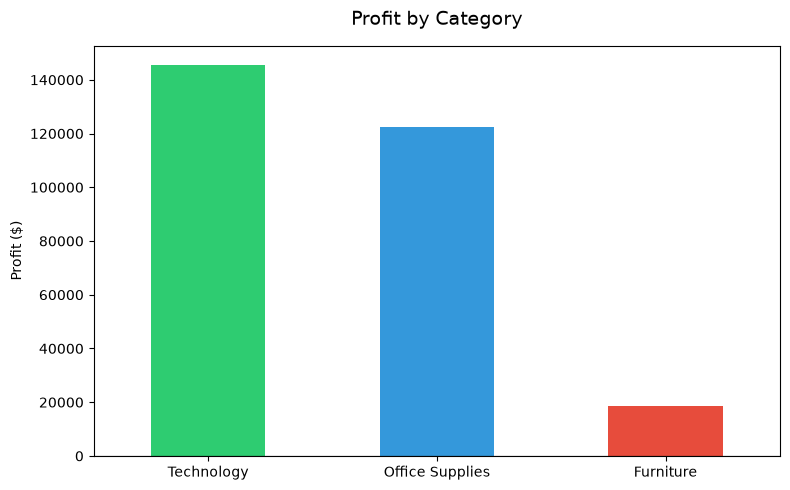

In [9]:
category = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_values("Profit", ascending=False)
)
print("\n--- Category Performance ---")
print(category)

# Gráfico melhorado - Lucro por Categoria
fig, ax = plt.subplots(figsize=(8, 5))
category["Profit"].plot(kind="bar", ax=ax, color=["#2ecc71", "#3498db", "#e74c3c"])
ax.set_title("Profit by Category", fontsize=14, pad=15)
ax.set_ylabel("Profit ($)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.axhline(0, color="black", linewidth=0.8)  # linha zero para referência
plt.tight_layout()
plt.show()

# ============================================
# 7. DISCOUNT ANALYSIS
# ============================================


--- Discount vs Margin ---
                 Sales       Profit  Orders    Margin
Discount                                             
0.00      1.087908e+06  320987.6032    4798  0.295050
0.10      5.436935e+04    9029.1770      94  0.166071
0.15      2.755852e+04    1418.9915      52  0.051490
0.20      7.645944e+05   90337.3060    3657  0.118151
0.30      1.032267e+05  -10369.2774     227 -0.100452
0.32      1.449346e+04   -2391.1377      27 -0.164980
0.40      1.164178e+05  -23057.0504     206 -0.198054
0.45      5.484974e+03   -2493.1111      11 -0.454535
0.50      5.891854e+04  -20506.4281      66 -0.348047
0.60      6.644700e+03   -5944.6552     138 -0.894646
0.70      4.062028e+04  -40075.3569     418 -0.986585
0.80      1.696376e+04  -30539.0392     300 -1.800252

--- Discount vs Average Margin ---
                Sales      Profit  Margin  Orders
Discount                                         
0.00      1087908.470  320987.603   0.295    4798
0.10        54369.351    9029.

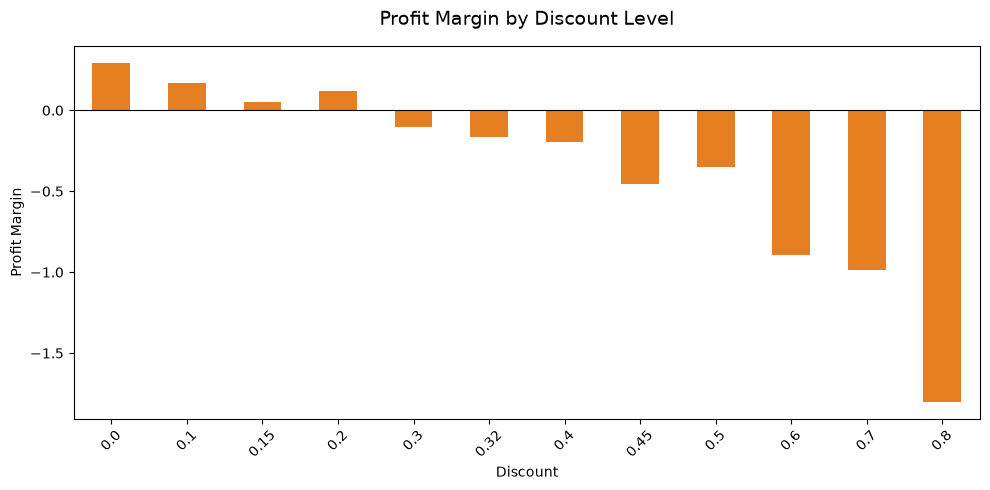

In [10]:
# Relação entre desconto e margem (média)
discount_analysis = (
    df.groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "count")
    )
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_index()
)
print("\n--- Discount vs Margin ---")
print(discount_analysis)

# Análise mais clara: margem média por faixa de desconto
print("\n--- Discount vs Average Margin ---")
print(discount_analysis[["Sales", "Profit", "Margin", "Orders"]].round(3))

# Gráfico: Margem de Lucro por nível de Desconto
fig, ax = plt.subplots(figsize=(10, 5))
discount_analysis["Margin"].plot(kind="bar", ax=ax, color="#e67e22")
ax.set_title("Profit Margin by Discount Level", fontsize=14, pad=15)
ax.set_ylabel("Profit Margin")
ax.set_xlabel("Discount")
ax.axhline(0, color="black", linewidth=0.8)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ============================================
# 8. TEMPORAL ANALYSIS
# ============================================


--- Yearly Performance ---
                  Sales      Profit    Margin
Order Year                                   
2014        484247.4981  49543.9741  0.102311
2015        470532.5090  61618.6037  0.130955
2016        609205.5980  81795.1743  0.134265
2017        733215.2552  93439.2696  0.127438


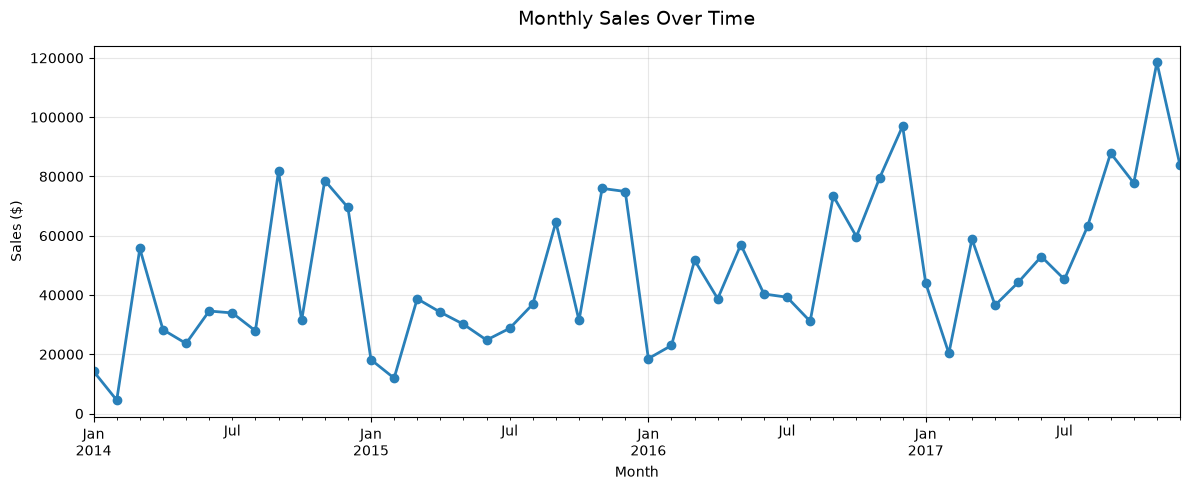

In [11]:
yearly = (
    df.groupby("Order Year")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
)
print("\n--- Yearly Performance ---")
print(yearly)

monthly_sales = df.groupby("Order Month")["Sales"].sum()
# Gráfico melhorado - Vendas Mensais
fig, ax = plt.subplots(figsize=(12, 5))
monthly_sales.plot(kind="line", ax=ax, marker="o", linewidth=2, color="#2980b9")
ax.set_title("Monthly Sales Over Time", fontsize=14, pad=15)
ax.set_ylabel("Sales ($)")
ax.set_xlabel("Month")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 9. REGIONAL ANALYSIS
# ============================================

In [12]:
region = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_values("Profit", ascending=False)
)
print("\n--- Region Performance ---")
print(region)


--- Region Performance ---
               Sales       Profit    Margin
Region                                     
West     725457.8245  108418.4489  0.149448
East     678781.2400   91522.7800  0.134834
South    391721.9050   46749.4303  0.119343
Central  501239.8908   39706.3625  0.079216


# ============================================
# 10. SUB-CATEGORY ANALYSIS
# ============================================


--- Sub-Category by Profit ---
                    Sales      Profit    Margin
Sub-Category                                   
Copiers       149528.0300  55617.8249  0.371956
Phones        330007.0540  44515.7306  0.134893
Accessories   167380.3180  41936.6357  0.250547
Paper          78479.2060  34053.5693  0.433918
Binders       203412.7330  30221.7633  0.148574
Chairs        328449.1030  26590.1663  0.080957
Storage       223843.6080  21278.8264  0.095061
Appliances    107532.1610  18138.0054  0.168675
Furnishings    91705.1640  13059.1436  0.142404
Envelopes      16476.4020   6964.1767  0.422676
Art            27118.7920   6527.7870  0.240711
Labels         12486.3120   5546.2540  0.444187
Machines      189238.6310   3384.7569  0.017886
Fasteners       3024.2800    949.5182  0.313965
Supplies       46673.5380  -1189.0995 -0.025477
Bookcases     114879.9963  -3472.5560 -0.030228
Tables        206965.5320 -17725.4811 -0.085645

--- Sub-Category by Margin (pior para melhor) ---
     

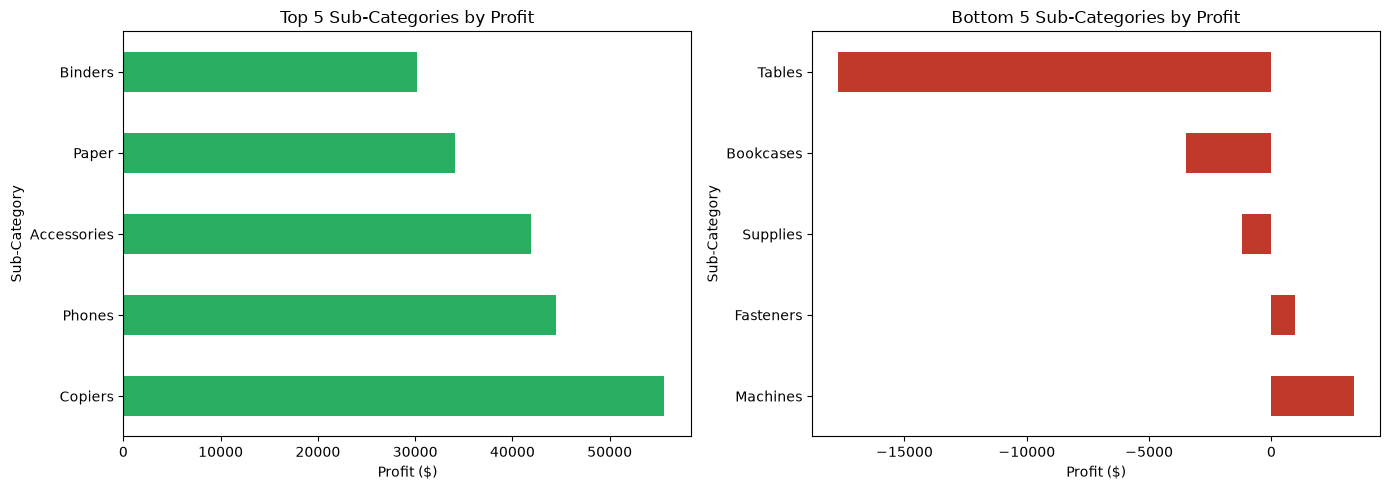

In [13]:
subcategory = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_values("Profit", ascending=False)
)
print("\n--- Sub-Category by Profit ---")
print(subcategory)

print("\n--- Sub-Category by Margin (pior para melhor) ---")
print(subcategory.sort_values("Margin"))

# Top 5 e Bottom 5 Sub-Categories por Lucro
top5 = subcategory.head(5)["Profit"]
bottom5 = subcategory.tail(5)["Profit"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5.plot(kind="barh", ax=axes[0], color="#27ae60")
axes[0].set_title("Top 5 Sub-Categories by Profit")
axes[0].set_xlabel("Profit ($)")

bottom5.plot(kind="barh", ax=axes[1], color="#c0392b")
axes[1].set_title("Bottom 5 Sub-Categories by Profit")
axes[1].set_xlabel("Profit ($)")

plt.tight_layout()
plt.show()

# ============================================
# 11. KEY FINDINGS
# ============================================

In [14]:
print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

print(f"\nTotal Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Margin: {overall_margin:.2%}")

print(f"\nBest Category by Profit: {category.index[0]}")
print(f"Worst Sub-Category by Margin: {subcategory.sort_values('Margin').index[0]}")
print(f"Best Region: {region.index[0]}")

# Segment
try:
    print(f"\nBest Segment by Profit: {segment.index[0]}")
except NameError:
    print("\nBest Segment by Profit: (ainda não calculado - rode a célula de Segment)")

# Ship Mode
try:
    print(f"Best Ship Mode by Profit: {ship_mode.index[0]}")
except NameError:
    print("Best Ship Mode by Profit: (ainda não calculado - rode a célula de Ship Mode)")

print(f"Average Shipping Days: {df['Shipping Days'].mean():.1f}")


KEY FINDINGS

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Margin: 12.47%

Best Category by Profit: Technology
Worst Sub-Category by Margin: Tables
Best Region: West

Best Segment by Profit: (ainda não calculado - rode a célula de Segment)
Best Ship Mode by Profit: (ainda não calculado - rode a célula de Ship Mode)
Average Shipping Days: 4.0


## 12. Segment Analysis

Sales, profit and margin are compared across customer segments (Consumer, Corporate, Home Office).

--- Segment Performance ---
                  Sales     Profit  Margin
Segment                                   
Consumer     1161401.34  134119.21    0.12
Corporate     706146.37   91979.13    0.13
Home Office   429653.15   60298.68    0.14


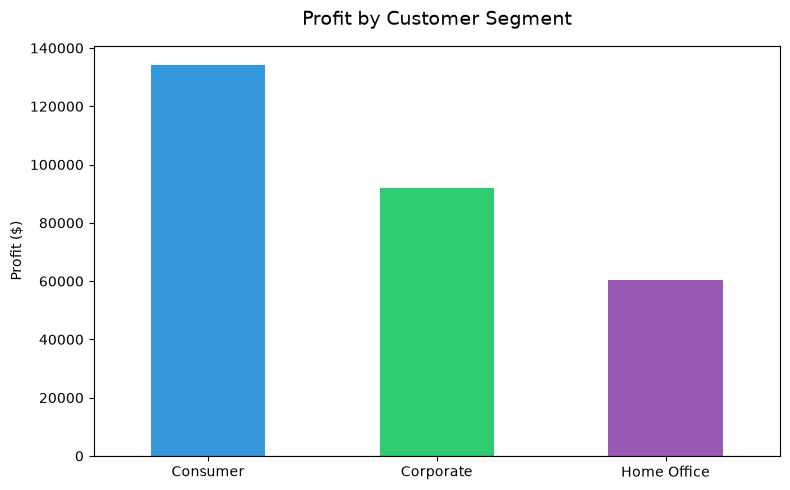

In [15]:
# Análise por Segment
segment = (
    df.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_values("Profit", ascending=False)
)

print("--- Segment Performance ---")
print(segment.round(2))

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
segment["Profit"].plot(kind="bar", ax=ax, color=["#3498db", "#2ecc71", "#9b59b6"])
ax.set_title("Profit by Customer Segment", fontsize=14, pad=15)
ax.set_ylabel("Profit ($)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 13. Ship Mode Analysis

Comparison of sales, profit and average shipping days across different shipping modes.

--- Ship Mode Performance ---
                     Sales     Profit  Orders  Avg_Shipping_Days  Margin
Ship Mode                                                               
Standard Class  1358215.74  164088.79    5968               5.01    0.12
Second Class     459193.57   57446.64    1945               3.24    0.13
First Class      351428.42   48969.84    1538               2.18    0.14
Same Day         128363.12   15891.76     543               0.04    0.12


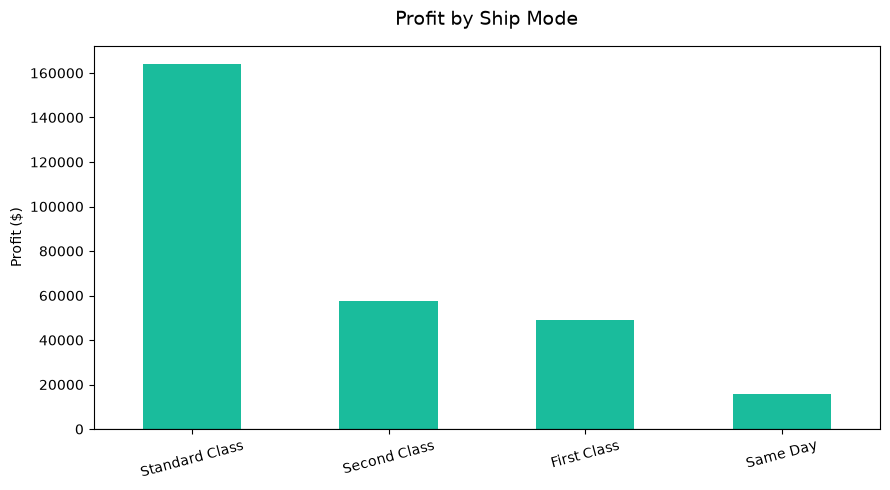

In [16]:
# Análise por Ship Mode
ship_mode = (
    df.groupby("Ship Mode")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "count"),
        Avg_Shipping_Days=("Shipping Days", "mean")
    )
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_values("Profit", ascending=False)
)

print("--- Ship Mode Performance ---")
print(ship_mode.round(2))

# Gráfico de lucro por modo de envio
fig, ax = plt.subplots(figsize=(9, 5))
ship_mode["Profit"].plot(kind="bar", ax=ax, color="#1abc9c")
ax.set_title("Profit by Ship Mode", fontsize=14, pad=15)
ax.set_ylabel("Profit ($)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 14. Shipping Days Analysis

Distribution of shipping time and its relationship with profitability.

--- Shipping Days Distribution ---
count    9994.00
mean        3.96
std         1.75
min         0.00
25%         3.00
50%         4.00
75%         5.00
max         7.00
Name: Shipping Days, dtype: float64

Value counts (top values):
Shipping Days
0     519
1     369
2    1334
3    1005
4    2774
5    2169
6    1203
7     621
Name: count, dtype: int64

--- Margin by Shipping Days (min 50 orders) ---
               Orders     Profit       Sales  Margin
Shipping Days                                       
0                 519  15385.968  124907.691   0.123
1                 369   7541.227   67975.331   0.111
2                1334  53118.114  368465.830   0.144
3                1005  26875.919  204659.599   0.131
4                2774  71134.774  631847.005   0.113
5                2169  58733.204  494357.084   0.119
6                1203  33275.968  240290.570   0.138
7                 621  20331.847  164697.750   0.123


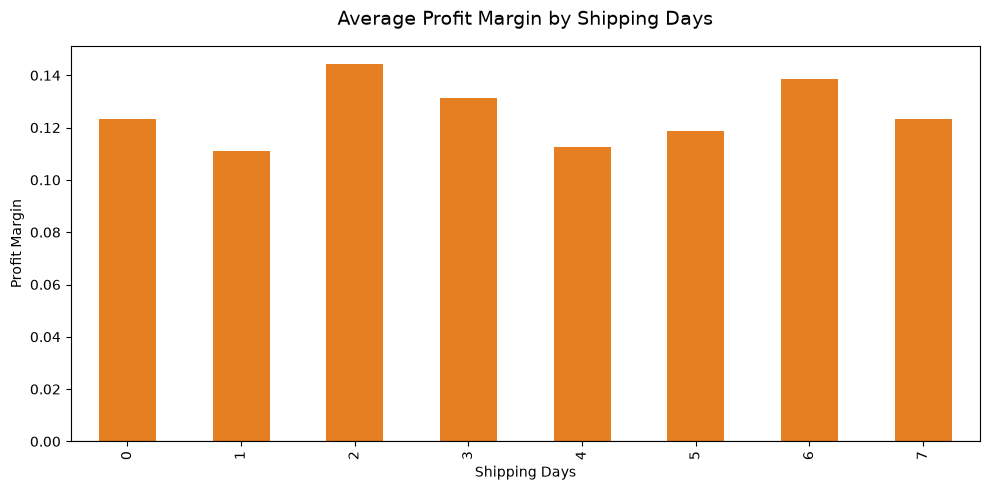

In [17]:
# Distribuição de dias de envio
print("--- Shipping Days Distribution ---")
print(df["Shipping Days"].describe().round(2))

print("\nValue counts (top values):")
print(df["Shipping Days"].value_counts().sort_index().head(10))

# Relação entre dias de envio e margem média
shipping_profit = (
    df.groupby("Shipping Days")
    .agg(
        Orders=("Order ID", "count"),
        Profit=("Profit", "sum"),
        Sales=("Sales", "sum")
    )
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
)

# Filtrar apenas dias com volume razoável de pedidos (evitar ruído)
shipping_profit = shipping_profit[shipping_profit["Orders"] >= 50]

print("\n--- Margin by Shipping Days (min 50 orders) ---")
print(shipping_profit.round(3))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
shipping_profit["Margin"].plot(kind="bar", ax=ax, color="#e67e22")
ax.set_title("Average Profit Margin by Shipping Days", fontsize=14, pad=15)
ax.set_ylabel("Profit Margin")
ax.set_xlabel("Shipping Days")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 15. Conclusions and Business Recommendations

This section summarizes the main findings and translates them into practical recommendations.

In [ ]:
print("="*60)
print("CONCLUSIONS AND BUSINESS RECOMMENDATIONS")
print("="*60)

print("""
MAIN FINDINGS
-------------
1. Overall performance is healthy: \~$2.30M in sales and \~$286K in profit 
   (overall margin around 12.4%).

2. Technology is the strongest category in both sales and profitability.
   Furniture underperforms significantly in margin.

3. The sub-category "Tables" is the biggest profit destroyer 
   (negative margin).

4. Higher discounts are clearly associated with lower (or negative) margins.
   Heavy discounting appears to hurt profitability.

5. The West region is the best performing region in sales, profit and margin.

6. Customer segments and shipping modes show different patterns, 
   indicating opportunities for targeted strategies.


BUSINESS RECOMMENDATIONS
------------------------
1. Review the pricing and discount strategy for Furniture, 
   especially the Tables sub-category. Consider reducing discounts 
   or discontinuing low-margin products.

2. Double down on Technology products — they deliver both volume and margin.

3. Investigate why the West region outperforms the others. 
   Replicate successful practices in Central, East and South if possible.

4. Be more selective with high discounts (40%+). 
   The data shows a clear negative relationship with profitability.

5. Analyze shipping modes more deeply: faster shipping may justify 
   higher prices if margin remains healthy.


LIMITATIONS
-----------
- This is an observational analysis. Correlation between discount 
  and lower margin does not prove causation.
- The dataset does not contain marketing spend, customer acquisition cost, 
  or inventory costs, which would allow a fuller profitability view.
- Results are specific to this Superstore dataset and may not generalize 
  to other businesses.
""")